In [1]:
# import torch

# context1 = torch.linspace(50, 100, 512+64).unsqueeze(0)
# context2 = (context1.clone()[0,:]*2).unsqueeze(0)
# contextTarget = context2+context1

# import matplotlib.pyplot as plt
# plt.plot(context1[0,:])
# plt.plot(context2[0,:])
# plt.plot(contextTarget[0,:])
# plt.show()

In [2]:
# torch.save(context1, './trainingData/context1.pt')
# torch.save(context2, './trainingData/context2.pt')
# torch.save(contextTarget, './trainingData/contextTarget.pt')

In [3]:
import numpy as np
import importlib
import sys
import os

# Ensure the 'scripts' directory is in the Python path
sys.path.append(os.path.join(os.getcwd(), 'scripts'))

# Dynamically import 'kernel-synth' from the 'scripts' directory
kernel_synth = importlib.import_module("kernel-synth")

context = list(
        kernel_synth.generate_time_series(max_kernels=5) for _ in range(3)
)

/home/amir/miniconda/envs/procGen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


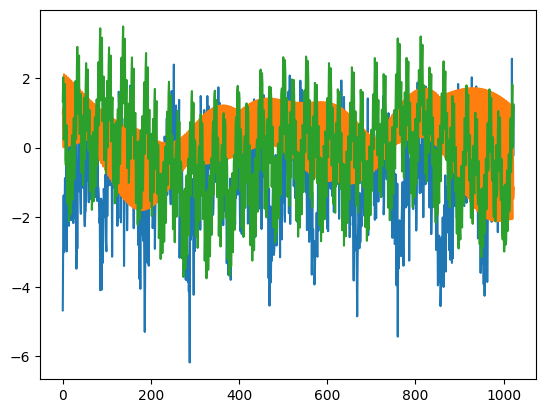

In [10]:
from matplotlib import pyplot as plt
for item in context:
    plt.plot(item['target'])

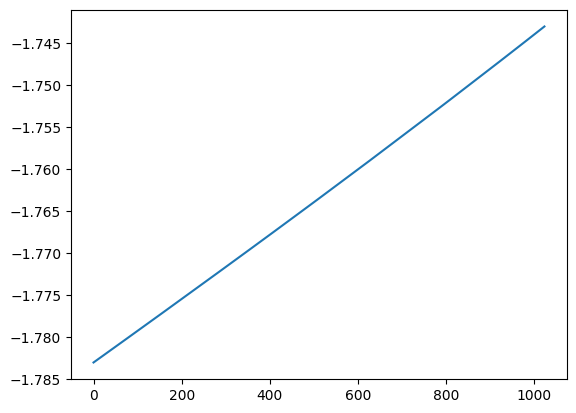

In [5]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    DotProduct,
    ExpSineSquared,
    Kernel,
    RationalQuadratic,
    WhiteKernel,
)

LENGTH = 1024
KERNEL_BANK = [
    ExpSineSquared(periodicity=365 * 2 / LENGTH),  # 0.5D
    ExpSineSquared(periodicity=50 / LENGTH),  # W
    ExpSineSquared(periodicity=365 / LENGTH),  # D
    DotProduct(sigma_0=0.0),
    DotProduct(sigma_0=10.0),
    RBF(length_scale=0.1),
    RBF(length_scale=10.0),
    RationalQuadratic(alpha=0.1),
    RationalQuadratic(alpha=1.0),
    WhiteKernel(noise_level=0.1),
    ConstantKernel(),
]

kernel = KERNEL_BANK[6]


# Define the Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel)

# Fit the Gaussian Process Regressor
ts = gpr.sample_y(np.linspace(0, 1, 1024)[:,None], n_samples=1)

plt.plot(ts)

In [6]:
ts.squeeze()

array([-1.78302979, -1.78299297, -1.78295515, ..., -1.74305657,
       -1.74301502, -1.74297319])

In [7]:
# Copyright Amazon.com, Inc. or its affiliates. All Rights Reserved.
# SPDX-License-Identifier: Apache-2.0

import argparse
import functools
from pathlib import Path
from typing import Optional

import numpy as np
from gluonts.dataset.arrow import ArrowWriter
from joblib import Parallel, delayed
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    DotProduct,
    ExpSineSquared,
    Kernel,
    RationalQuadratic,
    WhiteKernel,
)
from tqdm.auto import tqdm

LENGTH = 1024
KERNEL_BANK = [
    ExpSineSquared(periodicity=365 * 2 / LENGTH),  # 0.5D
    ExpSineSquared(periodicity=50 / LENGTH),  # W
    ExpSineSquared(periodicity=365 / LENGTH),  # D
    DotProduct(sigma_0=0.0),
    DotProduct(sigma_0=10.0),
    RBF(length_scale=0.1),
    RBF(length_scale=10.0),
    RationalQuadratic(alpha=0.1),
    RationalQuadratic(alpha=1.0),
    WhiteKernel(noise_level=0.1),
    ConstantKernel(),
]

def random_binary_map(a: Kernel, b: Kernel):
    """
    Applies a random binary operator (+ or *) with equal probability
    on kernels ``a`` and ``b``.

    Parameters
    ----------
    a
        A GP kernel.
    b
        A GP kernel.

    Returns
    -------
        The composite kernel `a + b` or `a * b`.
    """
    binary_maps = [lambda x, y: x + y, lambda x, y: x * y]
    return np.random.choice(binary_maps)(a, b)


def sample_from_gp_prior(
    kernel: Kernel, X: np.ndarray, random_seed: Optional[int] = None
):
    """
    Draw a sample from a GP prior.

    Parameters
    ----------
    kernel
        The GP covaraince kernel.
    X
        The input "time" points.
    random_seed, optional
        The random seed for sampling, by default None.

    Returns
    -------
        A time series sampled from the GP prior.
    """
    if X.ndim == 1:
        X = X[:, None]

    assert X.ndim == 2
    gpr = GaussianProcessRegressor(kernel=kernel)
    ts = gpr.sample_y(X, n_samples=1, random_state=random_seed)

    return ts


def sample_from_gp_prior_efficient(
    kernel: Kernel,
    X: np.ndarray,
    random_seed: Optional[int] = None,
    method: str = "eigh",
):
    """
    Draw a sample from a GP prior. An efficient version that allows specification
    of the sampling method. The default sampling method used in GaussianProcessRegressor
    is based on SVD which is significantly slower that alternatives such as `eigh` and
    `cholesky`.

    Parameters
    ----------
    kernel
        The GP covaraince kernel.
    X
        The input "time" points.
    random_seed, optional
        The random seed for sampling, by default None.
    method, optional
        The sampling method for multivariate_normal, by default `eigh`.

    Returns
    -------
        A time series sampled from the GP prior.
    """
    if X.ndim == 1:
        X = X[:, None]

    assert X.ndim == 2

    cov = kernel(X)
    ts = np.random.default_rng(seed=random_seed).multivariate_normal(
        mean=np.zeros(X.shape[0]), cov=cov, method=method
    )

    return ts


def generate_time_series(max_kernels: int = 5):
    """Generate a synthetic time series from KernelSynth.

    Parameters
    ----------
    max_kernels, optional
        The maximum number of base kernels to use for each time series, by default 5

    Returns
    -------
        A time series generated by KernelSynth.
    """
    while True:
        X = np.linspace(0, 1, LENGTH)

        # Randomly select upto max_kernels kernels from the KERNEL_BANK
        selected_kernels = np.random.choice(
            KERNEL_BANK, np.random.randint(1, max_kernels + 1), replace=True
        )

        # Combine the sampled kernels using random binary operators
        kernel = functools.reduce(random_binary_map, selected_kernels)

        # Sample a time series from the GP prior
        try:
            ts = sample_from_gp_prior(kernel=kernel, X=X)
        except np.linalg.LinAlgError as err:
            print("Error caught:", err)
            continue

        # The timestamp is arbitrary
        return {"start": np.datetime64("2000-01-01 00:00", "s"), "target": ts.squeeze()}

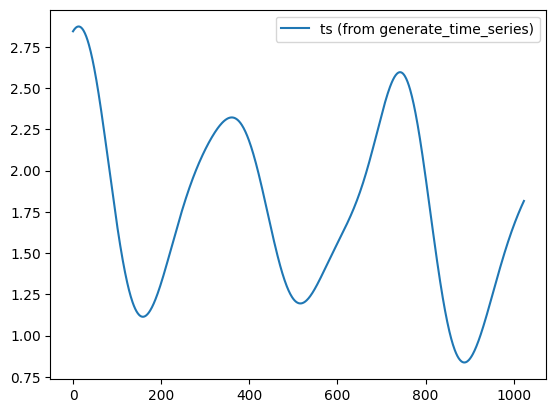

In [30]:

# Generate the original time series
ts = generate_time_series(max_kernels=5)  # Ensure max_kernels=1 for only one kernel


# Plot both series to compare
plt.plot(ts['target'], label='ts (from generate_time_series)')
plt.legend()
plt.show()
